MD**Intelligent Vision Systems · Lab 5 · Self-Driving Car Vision: Finding Lane Lines**  
Companion to **Lecture 5 (Part II) — Computer Vision for Self-Driving Cars**  
Dr. Muhammad Kazim · Department of Intelligent Systems, University of Lahore

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Kazimbalti/intelligent-vision-systems/blob/main/LAB/Lab_5/07-leaderboard.ipynb) &nbsp; [Lecture 5 Part II slides](https://kazimbalti.github.io/intelligent-vision-systems/lectures/05_SDC_Lane_Finding.html#/assignment-2-finding-lane-lines) &nbsp; [All Lab 5 notebooks](https://kazimbalti.github.io/intelligent-vision-systems/labs.html#lab-5-lane-lines)

# Lab 5G · Lane-Finding Leaderboard 🏁

How good is your lane finder **really**? This notebook scores any lane finder on **92 frames** against labelled lane
lines: 46 **clean** frames (40 from the two Udacity videos + the 6 test images) and 46 **hard** copies of them, each degraded
by night, tree shadows, haze, sensor noise, glare or faded paint. It gives you a line to send to the TA for the
**[class leaderboard](https://kazimbalti.github.io/intelligent-vision-systems/labs.html#lab-5-leaderboard)**.

**The rules**

* Your function `lane_lines(rgb)` gets an RGB image and returns `{"left": (x1, y1, x2, y2), "right": (x1, y1, x2, y2)}`
  — one straight line per lane (any two points on it), or `None` for a lane you cannot find.
* A lane counts as **correct** if its average horizontal error over the lower part of the image is **under 20 pixels**.
* Ranking: **overall accuracy** first, then **mean error**, then **speed** (frames/s). The clean/hard split tells you
  whether your finder is accurate, robust, or both.
* No hard-coding answers per frame — the TA may re-run your notebook. The labels were made with the instructor's
  reference pipeline and checked by eye, so the best possible score is close to (not exactly) 100%.

In [1]:
# Setup (only needed on Google Colab or a fresh environment).
# Uncomment the next line to install the packages this notebook uses:
# !pip install -q opencv-python numpy matplotlib

import os, urllib.request

# Fetch the lab images if they are not next to the notebook.
RAW = "https://raw.githubusercontent.com/Kazimbalti/intelligent-vision-systems/main/LAB/Lab_5"
for f in ['lab5_checks.py']:
    if not os.path.exists(f):
        os.makedirs(os.path.dirname(f) or ".", exist_ok=True)
        urllib.request.urlretrieve(f"{RAW}/{f}", f)
print("data ready")

data ready


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import lab5_checks as C

gt = C.load_benchmark()          # downloads 92 frames (~6 MB) the first time
print(len(gt["frames"]), "frames ready")

92 frames ready


MD## 1. The baseline to beat

The plain lab pipeline: grayscale → blur → Canny → region → Hough → fit one line through each side's segment end-points.
No colour selection, no length weighting, no outlier rejection.

In [3]:
def baseline_lane_lines(rgb):
    h, w = rgb.shape[:2]
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(cv2.GaussianBlur(gray, (5, 5), 0), 50, 150)
    mask = np.zeros_like(edges)
    roi = np.array([[(0.05 * w, h), (0.45 * w, 0.6 * h), (0.55 * w, 0.6 * h), (0.95 * w, h)]], np.int32)
    cv2.fillPoly(mask, roi, 255)
    segs = cv2.HoughLinesP(cv2.bitwise_and(edges, mask), 2, np.pi / 180, 15, minLineLength=40, maxLineGap=20)
    out = {"left": None, "right": None}
    if segs is None:
        return out
    for side in out:
        xs, ys = [], []
        for x1, y1, x2, y2 in segs.reshape(-1, 4):
            if x1 == x2:
                continue
            m = (y2 - y1) / (x2 - x1)
            if (side == "left" and m < -0.3) or (side == "right" and m > 0.3):
                xs += [x1, x2]; ys += [y1, y2]
        if len(xs) >= 2:
            a, b = np.polyfit(ys, xs, 1)                 # x = a*y + b (well-behaved for steep lines)
            out[side] = (a * h + b, h, a * 0.6 * h + b, 0.6 * h)
    return out

baseline = C.score(baseline_lane_lines, gt)

Accuracy: 95.1% overall  (clean 100.0% · hard 90.2%) · mean error 7.2px · 217.1 frames/s
Hardest cases: hard_syl_432_haze.jpg (left, 100px), hard_syl_502_glare.jpg (right, 100px), hard_syl_641_haze.jpg (left, 100px)


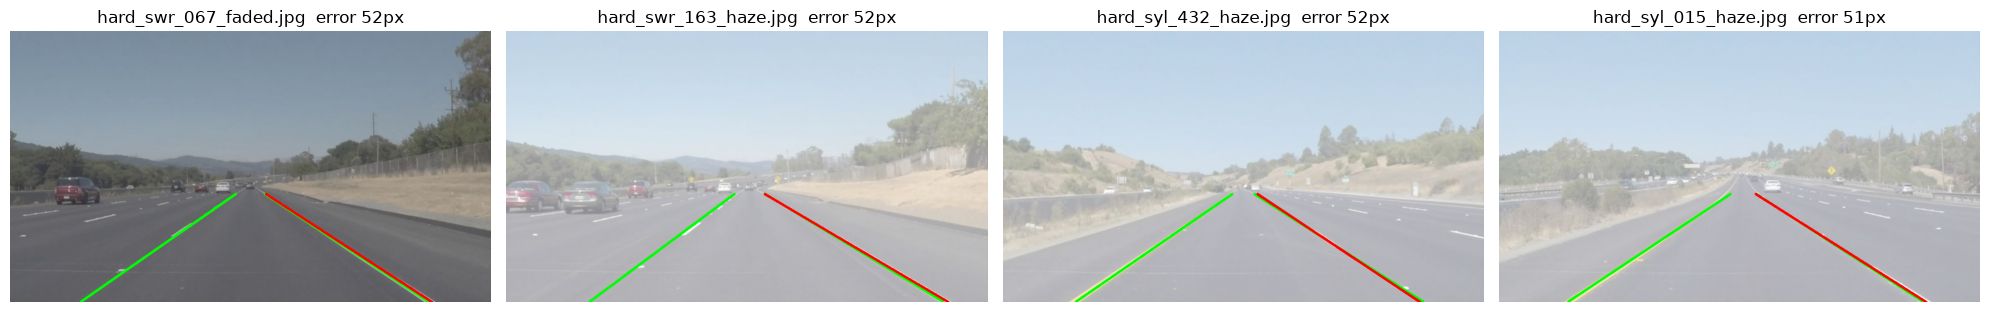

In [4]:
C.show_worst(baseline_lane_lines, k=4, gt=gt)

MD## 2. Your lane finder

Paste the line-finding part of your Assignment 2 pipeline below (everything **before** drawing). Ideas that move you
up the leaderboard:

* contrast normalisation (e.g. CLAHE) or Canny thresholds set from the image's median brightness — for night and haze
* HLS / LAB colour selection — but beware: **fixed** colour thresholds collapse on the hard frames (try it!)
* region vertices as **fractions** of the image size
* reject outlier slopes; weight segments by length; use the **median** instead of the mean
* sanity checks: lanes must not cross, lane width must be plausible
* speed: smaller blur kernel, fewer Hough votes, downscale the image (remember to scale the result back!)

In [5]:
def my_lane_lines(rgb):
    # TODO: replace this with your own pipeline - it must return {"left": (x1, y1, x2, y2) or None, "right": ...}
    return baseline_lane_lines(rgb)

mine = C.score(my_lane_lines, gt)

Accuracy: 95.1% overall  (clean 100.0% · hard 90.2%) · mean error 7.2px · 286.3 frames/s
Hardest cases: hard_syl_432_haze.jpg (left, 100px), hard_syl_502_glare.jpg (right, 100px), hard_syl_641_haze.jpg (left, 100px)


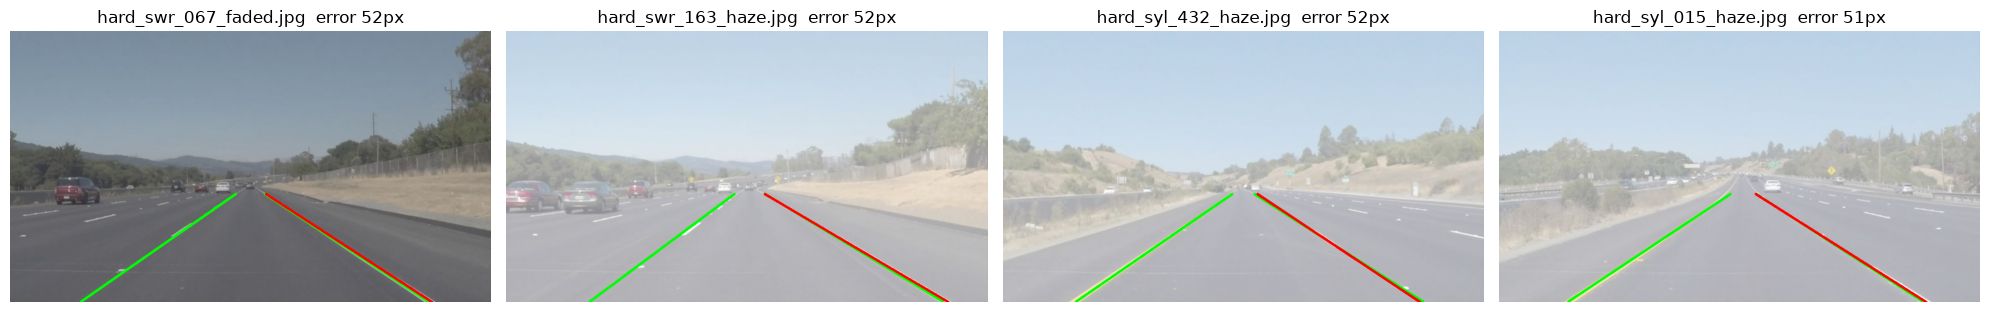

In [6]:
C.show_worst(my_lane_lines, k=4, gt=gt)

MD## 3. Submit to the class leaderboard

Put your **team name** (both partners), run the cell and send the printed line to your TA.

In [7]:
C.submission("Team name - Partner A & Partner B", mine)

Copy this line and send it to your TA:
{"team": "Team name - Partner A & Partner B", "accuracy": 95.1, "clean": 100.0, "hard": 90.2, "mean_error_px": 7.2, "fps": 286.3}


'{"team": "Team name - Partner A & Partner B", "accuracy": 95.1, "clean": 100.0, "hard": 90.2, "mean_error_px": 7.2, "fps": 286.3}'

MD## Reflect

* Which frames are hardest for your finder (see `show_worst`)? What do they have in common?
* Which single change improved your score the most? Was it worth the speed cost?